In [ ]:
#evaluation of miniProt result using the poaceae consensus query
#author: Sheng-Kai Hsu
#created: 2024.08.05
#last edited: 2025.04.04
rm(list=ls())
PHYLOGWAS_ROOT <- Sys.getenv("PHYLOGWAS_ROOT", unset = "/workdir/sh2246/p_phyloGWAS")

In [5]:
library(rtracklayer)
library(Biostrings)
library(limma)
library(scales)
library(LSD)
library(parallel)
library(tidyverse)

In [ ]:
queryFa = readAAStringSet(file.path(PHYLOGWAS_ROOT, "output/poaceaeHelixerOG_ancSeq_gapRemoved_v2_20240909.fa"))
queryFa_length=width(queryFa)
names(queryFa_length)=names(queryFa)


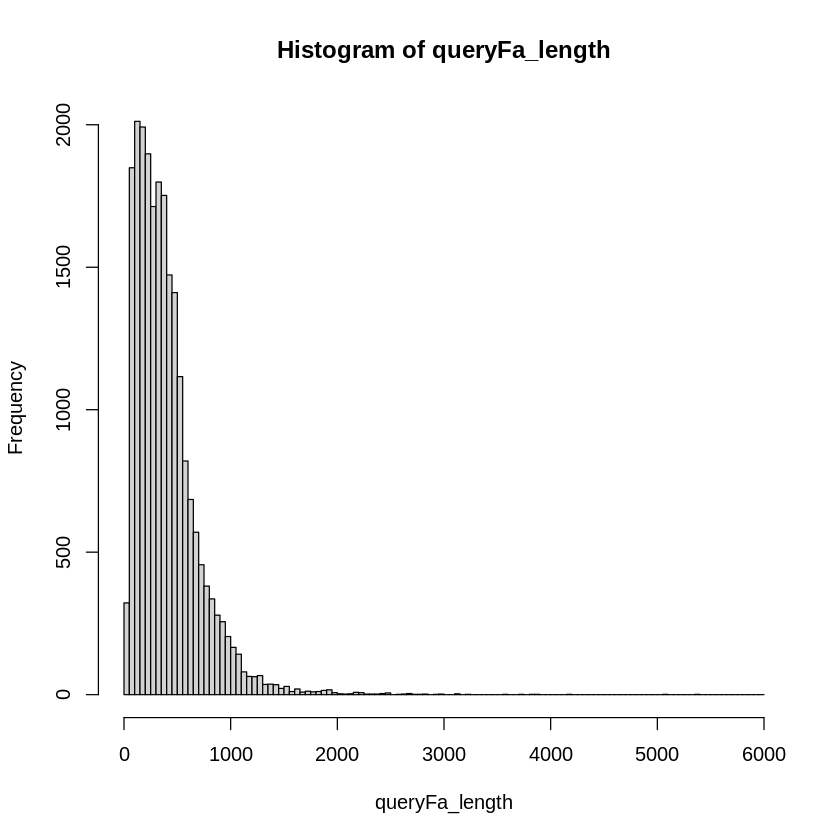

In [7]:
hist(queryFa_length,breaks= seq(0,6000,50))

In [ ]:
png(file.path(PHYLOGWAS_ROOT, "output/figure/suppFig/suppFig_genomicPipeline_c.png"),width = 4.5,height = 4.5,
    units = "cm", res  = 600, pointsize = 4)
par(mar= c(4,4,1,1))
hist(queryFa_length,breaks= seq(0,6000,50),main  = "", xlab = "recontructed ancestral sequence length (a.a.)",
     col = "darkblue",border = "darkblue")
dev.off()

In [8]:
calculate_range <- function(start, end) {
  intervals <- data.frame(Start = start, End = end)
  intervals <- intervals[order(intervals$Start), ]
  
  # Merge overlapping intervals
  merged_intervals <- Reduce(function(acc, current) {
    if (is.null(acc)) {
      return(current)
    }
    last <- acc[nrow(acc), ]
    if (last$End >= current$Start) {
      acc[nrow(acc), 'End'] <- max(last$End, current$End)
    } else {
      acc <- rbind(acc, current)
    }
    acc
  }, split(intervals, 1:nrow(intervals)), init = NULL)
  
  # Calculate total range
  total_range <- sum(merged_intervals$End - merged_intervals$Start)
  return(total_range)
}


In [ ]:
eval_scaffold = function(j){
    gff_original = readGFF(paste0(file.path(PHYLOGWAS_ROOT, "output/orthofinderMiniProt/"),j,".gff"))
    if(nrow(gff_original)>0) {
        gff.mrna_original = gff_original[gff_original[,3]=="mRNA",]

        queryStat_original = strsplit2(gff.mrna_original$Target," ")
        queryStat_original = as.data.frame(queryStat_original)
        colnames(queryStat_original) = c("query","start","end")
        queryStat_original$range = as.numeric(queryStat_original[,3])-as.numeric(queryStat_original[,2])+1

        qcov_original=c()
        for (i in unique(queryStat_original[,1])){
          qcov_original=c(qcov_original,queryStat_original[queryStat_original[,1]==i,4]/queryFa_length[i])
        }
        queryStat_original$coverage = qcov_original

        queryStat_original[,2] = as.numeric(queryStat_original[,2])
        queryStat_original[,3] = as.numeric(queryStat_original[,3])

        queryLengthCov_original <- queryStat_original %>% group_by(query) %>% 
        summarise(TotalRange = calculate_range(start, end))
        queryLengthCov_original = as.data.frame(queryLengthCov_original)
        rownames(queryLengthCov_original)=queryLengthCov_original[,1]

        out = queryFa_length[queryLengthCov_original[,1]]-queryLengthCov_original[,2]
        names(out) = queryLengthCov_original[,1]
        return(out)
    }
    else return(NULL)
}


In [ ]:
sampleID = gsub(".gff","",list.files(file.path(PHYLOGWAS_ROOT, "output/orthofinderMiniProt/")))
missBP = simplify2array(mclapply(sampleID,eval_scaffold,mc.cores = 10))

In [12]:
names(missBP) = sampleID
missBP_noMissing = simplify2array(missBP[!sapply(missBP,length)==0])
missBP_noMissing = sapply(missBP_noMissing,function(x) as.numeric(x[names(queryFa_length)]))
rownames(missBP_noMissing) = names(queryFa_length)
missBP_naFilled = apply(missBP_noMissing,2,function(x) {
    x[is.na(x)] = queryFa_length[is.na(x)]
    return(x)
})

In [ ]:
metadata = read.delim(file.path(PHYLOGWAS_ROOT, "data/Poaceae_metadata_highErrorFiltered_2025.10.08.tsv"),header = T)

In [16]:
missBP_cat = apply(missBP_naFilled,2,function(x) table(as.numeric(cut(x,c(-10,0,30,90,300,6e3))))[as.character(1:5)])
missBP_cat[is.na(missBP_cat)]=0

In [17]:
cov_cat = apply(missBP_naFilled,2,function(x) table(12-as.numeric(cut(1-x/queryFa_length,seq(-0.1,1,0.1))))[as.character(1:11)])

cov_cat[is.na(cov_cat)] = 0

In [29]:
missBP_cat = missBP_cat[,metadata$assemblyID]
cov_cat = cov_cat[,metadata$assemblyID]

Loading required package: viridisLite


Attaching package: ‘viridis’


The following object is masked from ‘package:scales’:

    viridis_pal




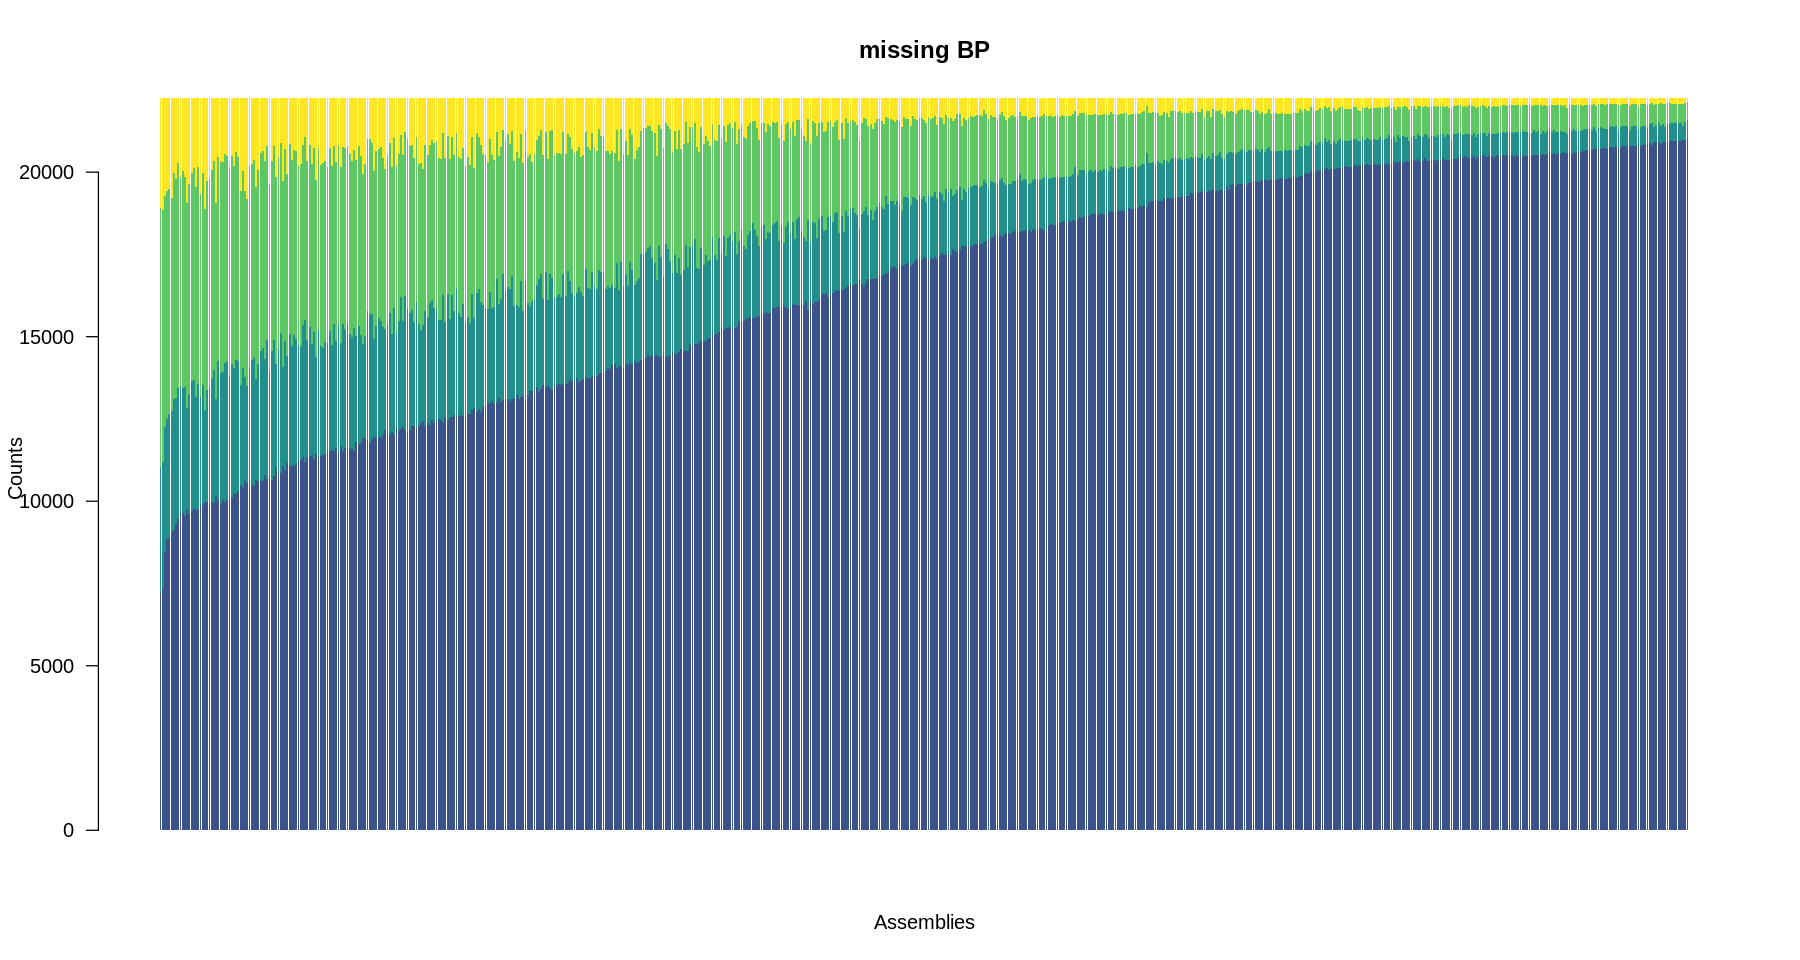

In [35]:
library(viridis)
options(repr.plot.width = 15,repr.plot.height = 8)
barplot(missBP_cat[,order(cov_cat[1,])],col =viridis(5),border = NA,las = 2,xaxt='n',
        xlab = "Assemblies",ylab = "Counts",main = "missing BP")

In [ ]:
png(file.path(PHYLOGWAS_ROOT, "output/figure/suppFig/suppFig_genomicPipeline_d2.png"),width = 8.2, height = 3.4,
    units = "cm",res = 1200,pointsize = 4)
par(mar= c(0,3,3,0))
barplot(cov_cat[,order(cov_cat[1,])],col = viridis(12),border = viridis(12),xaxt='n',
        xlab = "",ylab = "Counts",main = "Coverage per OG",,xlim = c(0,1050),
        legend.text = c("(0.9,1]","(0.8,0.9]","(0.7,0.8]","(0.6,0.7]","(0.5,0.6]","(0.4,0.5]",
                        "(0.3,0.4]","(0.2,0.3]","(0.1,0.2]","(0,0.1]","0"))
dev.off()

In [ ]:
write.table(missBP_cat,file.path(PHYLOGWAS_ROOT, "output/figure/suppFig/suppFig_genomicPipeline_missBP_data.txt"),quote = F,sep = "\t",col.names = NA)
write.table(cov_cat,file.path(PHYLOGWAS_ROOT, "output/figure/suppFig/suppFig_genomicPipeline_d2_data.txt"),quote = F,sep = "\t",col.names = NA)

In [ ]:
eval_contig = function(j){
    gff_original = readGFF(paste0(file.path(PHYLOGWAS_ROOT, "output/orthofinderMiniProt/"),j,".gff"))

    if(nrow(gff_original)>0) {
        gff.mrna_original = gff_original[gff_original[,3]=="mRNA",]

        queryStat_original = strsplit2(gff.mrna_original$Target," ")
        queryStat_original = as.data.frame(queryStat_original)
        colnames(queryStat_original) = c("query","start","end")
        queryStat_original$range = as.numeric(queryStat_original[,3])-as.numeric(queryStat_original[,2])+1

        out = table(queryStat_original[,1])[names(queryFa_length)]
        names(out) = names(queryFa_length)
        return(out)
    }
    else return(NULL)
}


In [39]:
numContig = simplify2array(mclapply(sampleID,eval_contig,mc.cores = 10))
# numContig_noMissing = simplify2array(numContig[!sapply(numContig,length)==0])

In [40]:
colnames(numContig) = sampleID
numContig= numContig[,metadata$assemblyID]

In [41]:
numContig_freq = apply(numContig,2,function(x) table(x)[as.character(1:31)])
numContig_freq[is.na(numContig_freq)] = 0

In [42]:
numContig_freq_bin = rbind(numContig_freq[1:8,],colSums(numContig_freq[-(1:8),]))

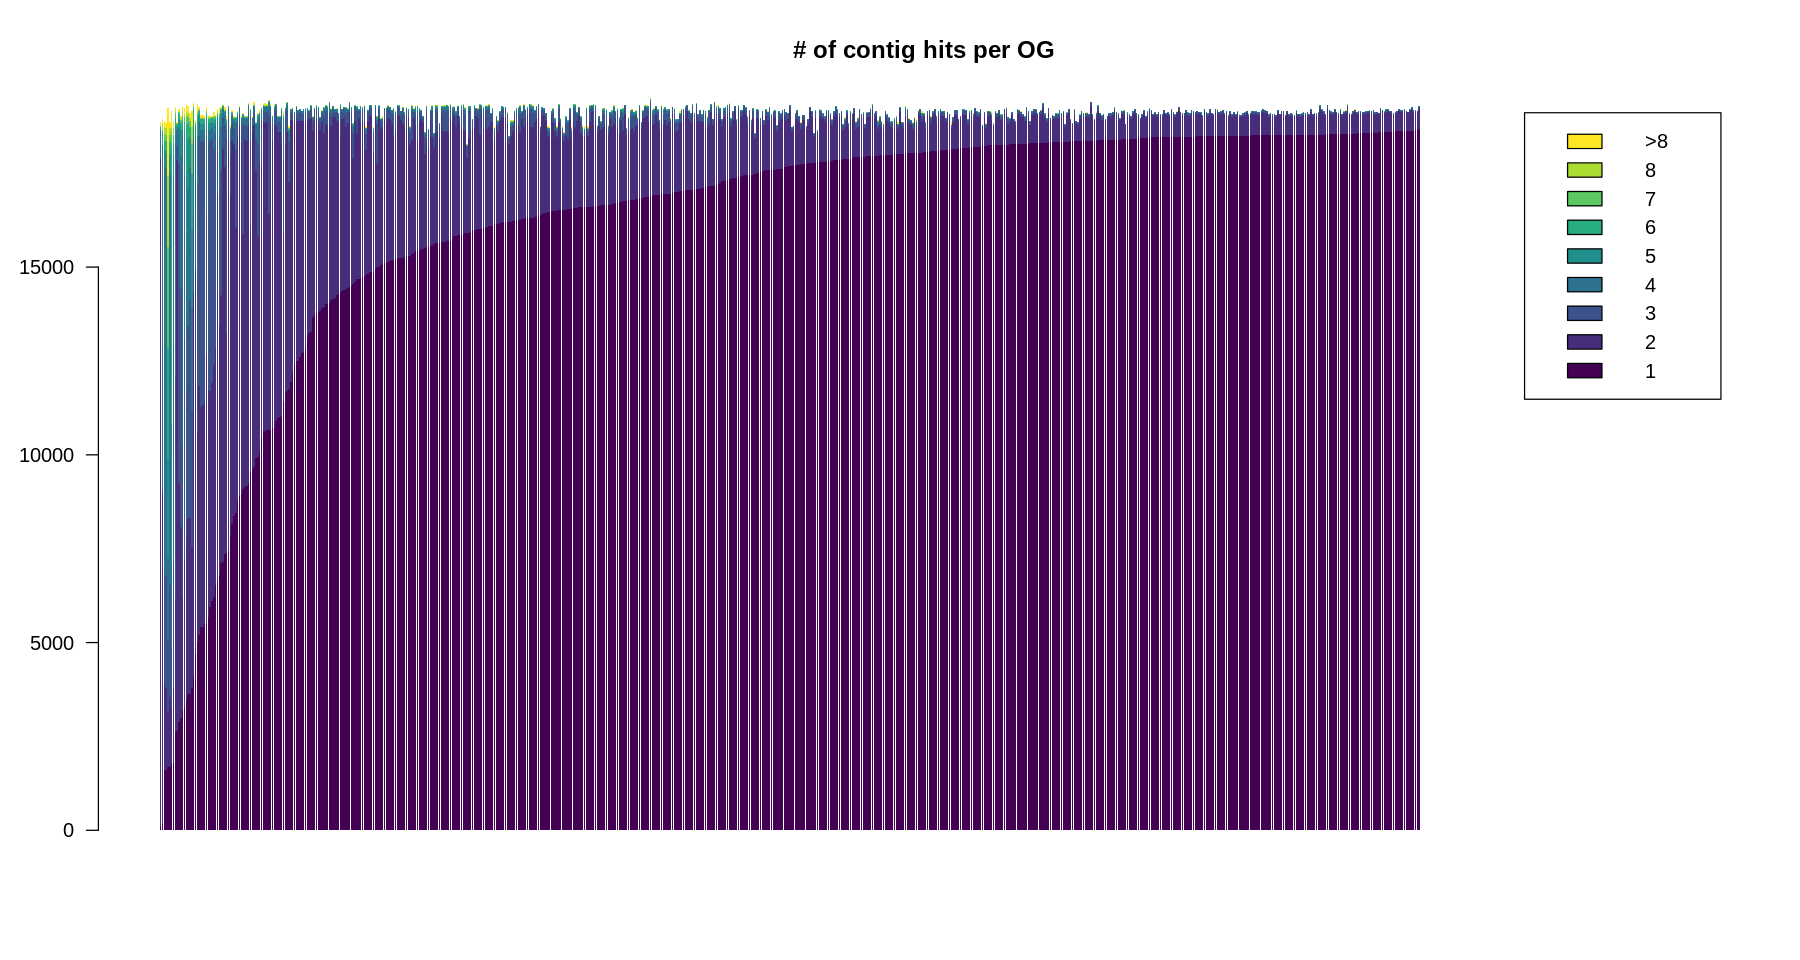

In [43]:
mybpcol = viridis(9)
barplot(numContig_freq_bin[,order(numContig_freq_bin[1,])],col = mybpcol,border = NA,las =2,xlim = c(0,1000),
        legend.text = c(1:8,">8"),xaxt = 'n',main = "# of contig hits per OG")

In [ ]:
png(file.path(PHYLOGWAS_ROOT, "output/figure/suppFig/suppFig_genomicPipeline_d1.png"),width = 8.2, height = 3.4,
    units = "cm",res = 1200,pointsize = 4)
par(mar = c(0,3,3,0))
# mybpcol = rev(rainbow(10)[1:9])
barplot(numContig_freq_bin[,order(numContig_freq_bin[1,])],col = mybpcol,border = mybpcol,xlim = c(0,1000),
        legend.text = c(1:8,">8"),xaxt = 'n',main = "# of hits per OG",xlab = "", ylab = "count")
dev.off()

In [ ]:
write.table(numContig_freq_bin,file.path(PHYLOGWAS_ROOT, "output/figure/suppFig/suppFig_genomicPipeline_d1_data.txt"),quote = F,sep = "\t",col.names = NA)